In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Transformation

In [2]:
food = pd.read_csv("/content/food.csv")
food_nutrient = pd.read_csv("/content/food_nutrient.csv")
nutrient = pd.read_csv("/content/nutrient.csv")

In [ ]:
print(food.shape)
print(food_nutrient.shape)
print(nutrient.shape)

(7793, 5)
(644125, 11)
(474, 5)


In [ ]:
food.head()

,fdc_id,data_type,description,food_category_id,publication_date
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,2019-04-01
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18,2019-04-01
2,167514,sr_legacy_food,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18,2019-04-01
3,167515,sr_legacy_food,"George Weston Bakeries, Thomas English Muffins",18,2019-04-01
4,167516,sr_legacy_food,"Waffles, buttermilk, frozen, ready-to-heat",18,2019-04-01


In [ ]:
food_nutrient.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.88,1,46.0,NaN,NaN,NaN,NaN,NaN
1,1283675,167512,1007,3.50,1,46.0,NaN,NaN,NaN,NaN,NaN
2,1283676,167512,1062,1286.00,0,49.0,NaN,NaN,NaN,NaN,NaN
3,1283677,167512,1079,1.20,1,46.0,NaN,NaN,NaN,NaN,NaN
4,1283678,167512,1089,2.12,1,46.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
nutrient.head()

,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


In [ ]:
food['data_type'].value_counts()

,count
data_type,
sr_legacy_food,7793


In [ ]:
nutrient[nutrient.name.str.contains('potassi', case=False)]

,id,name,unit_name,nutrient_nbr,rank
93,1092,"Potassium, K",MG,306.0,5700.0


In [3]:
important_nutrients = [
    1008,  # Energy
    1003,  # Protein
    1004,  # Total Fat
    1258,  # Saturated Fat
    1257,  # Trans Fat
    1005,  # Carbohydrate
    2000,  # Sugars
    1079,  # Fiber
    1093,  # Sodium
    1253,  # Cholesterol
    1092,  # Potassium
]

nutrient_map = (
    nutrient[nutrient['id'].isin(important_nutrients)]
    .set_index('id')['name']
    .to_dict()
)

nutrient_map

{1003: 'Protein',
 1004: 'Total lipid (fat)',
 1005: 'Carbohydrate, by difference',
 1008: 'Energy',
 1079: 'Fiber, total dietary',
 1092: 'Potassium, K',
 1093: 'Sodium, Na',
 1253: 'Cholesterol',
 1257: 'Fatty acids, total trans',
 1258: 'Fatty acids, total saturated',
 2000: 'Sugars, Total'}

In [4]:
food_nutrient = food_nutrient[
    food_nutrient['nutrient_id'].isin(important_nutrients)
]
food_nutrient.shape

(78658, 11)

In [ ]:
food_nutrient.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.880,1,46.0,NaN,NaN,NaN,NaN,NaN
3,1283677,167512,1079,1.200,1,46.0,NaN,NaN,NaN,NaN,NaN
5,1283679,167512,1093,1059.000,1,46.0,NaN,NaN,NaN,NaN,NaN
6,1283680,167512,1253,0.000,1,46.0,NaN,NaN,NaN,NaN,NaN
7,1283681,167512,1257,4.412,1,46.0,NaN,NaN,NaN,NaN,NaN


In [5]:
df = food_nutrient.pivot(
    index='fdc_id',
    columns='nutrient_id',
    values='amount'
).reset_index()
df = df.rename(columns=nutrient_map)
df.shape

(7793, 12)

In [ ]:
df.head()

nutrient_id,fdc_id,Protein,Total lipid (fat),"Carbohydrate, by difference",Energy,"Fiber, total dietary","Potassium, K","Sodium, Na",Cholesterol,"Fatty acids, total trans","Fatty acids, total saturated","Sugars, Total"
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,1059.0,0.0,4.412,2.941,5.88
1,167513,4.34,11.27,53.42,330.0,1.4,NaN,780.0,0.0,4.290,3.250,21.34
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,2182.0,NaN,NaN,NaN,NaN
3,167515,8.00,1.80,46.00,232.0,NaN,NaN,345.0,NaN,0.082,0.308,NaN
4,167516,6.58,9.22,41.05,273.0,2.2,126.0,621.0,15.0,NaN,1.898,4.30


In [6]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(',', '')
    .str.replace('(', '')
    .str.replace(')', '')
)

In [7]:
df = df.merge(food[['fdc_id', 'description', 'food_category_id']],
              on='fdc_id',
              how='left')

In [ ]:
df.head()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total,description,food_category_id
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,1059.0,0.0,4.412,2.941,5.88,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18
1,167513,4.34,11.27,53.42,330.0,1.4,NaN,780.0,0.0,4.290,3.250,21.34,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,2182.0,NaN,NaN,NaN,NaN,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18
3,167515,8.00,1.80,46.00,232.0,NaN,NaN,345.0,NaN,0.082,0.308,NaN,"George Weston Bakeries, Thomas English Muffins",18
4,167516,6.58,9.22,41.05,273.0,2.2,126.0,621.0,15.0,NaN,1.898,4.30,"Waffles, buttermilk, frozen, ready-to-heat",18


# Preprocessing

## Analysis

In [ ]:
df.head()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total,description,food_category_id
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,1059.0,0.0,4.412,2.941,5.88,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18
1,167513,4.34,11.27,53.42,330.0,1.4,NaN,780.0,0.0,4.290,3.250,21.34,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,2182.0,NaN,NaN,NaN,NaN,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18
3,167515,8.00,1.80,46.00,232.0,NaN,NaN,345.0,NaN,0.082,0.308,NaN,"George Weston Bakeries, Thomas English Muffins",18
4,167516,6.58,9.22,41.05,273.0,2.2,126.0,621.0,15.0,NaN,1.898,4.30,"Waffles, buttermilk, frozen, ready-to-heat",18


In [ ]:
df.tail()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total,description,food_category_id
7788,175300,26.83,1.80,0.0,131.0,0.0,313.0,56.0,61.0,NaN,0.60,NaN,"Game meat, buffalo, water, cooked, roasted",17
7789,175301,22.95,1.45,0.0,111.0,0.0,312.0,58.0,55.0,NaN,0.53,NaN,"Game meat, elk, raw",17
7790,175302,30.19,1.90,0.0,146.0,0.0,328.0,61.0,73.0,NaN,0.70,NaN,"Game meat, elk, cooked, roasted",17
7791,175303,20.60,2.31,0.0,109.0,0.0,385.0,82.0,57.0,NaN,0.71,NaN,"Game meat, goat, raw",17
7792,175304,27.10,3.03,0.0,143.0,0.0,405.0,86.0,75.0,NaN,0.93,0.0,"Game meat, goat, cooked, roasted",17


In [ ]:
df.describe()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total,food_category_id
count,7793.000000,7793.000000,7793.000000,7793.000000,7793.000000,7231.000000,7516.000000,7709.000000,7394.000000,4179.000000,7450.000000,6007.000000,7793.000000
mean,171408.000000,11.926873,10.687361,19.569788,220.243118,1.979118,286.798563,292.012583,45.045307,0.298328,3.643457,7.618170,12.632619
std,2249.789657,10.859968,16.381682,25.705634,168.752033,4.310590,387.471573,991.963441,126.327041,1.599427,6.755649,14.782095,6.062021
min,167512.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,169460.000000,2.270000,0.800000,0.000000,91.000000,0.000000,132.000000,33.000000,0.000000,0.000000,0.185000,0.000000,9.000000
50%,171408.000000,8.980000,5.060000,7.600000,183.000000,0.300000,238.000000,74.000000,8.000000,0.008000,1.634000,1.340000,13.000000
75%,173356.000000,20.770000,13.500000,27.120000,317.000000,2.300000,340.000000,347.000000,71.000000,0.179000,4.379500,7.420000,17.000000
max,175304.000000,88.320000,100.000000,100.000000,902.000000,79.000000,16500.000000,38758.000000,3100.000000,42.851000,95.600000,99.800000,25.000000


In [ ]:
df.dtypes

,0
fdc_id,int64
protein,float64
total_lipid_fat,float64
carbohydrate_by_difference,float64
energy,float64
fiber_total_dietary,float64
potassium_k,float64
sodium_na,float64
cholesterol,float64
fatty_acids_total_trans,float64


In [8]:
food_category = pd.read_csv('/content/food_category.csv')
food_category.shape

(28, 3)

In [ ]:
food_category[['id', 'description']]

,id,description
0,1,Dairy and Egg Products
1,2,Spices and Herbs
2,3,Baby Foods
3,4,Fats and Oils
4,5,Poultry Products
5,6,"Soups, Sauces, and Gravies"
6,7,Sausages and Luncheon Meats
7,8,Breakfast Cereals
8,9,Fruits and Fruit Juices
9,10,Pork Products


In [ ]:
category_counts = df["food_category_id"].value_counts()
category_counts

,count
food_category_id,
13,954
11,814
18,517
17,464
5,383
14,366
19,358
9,355
3,345


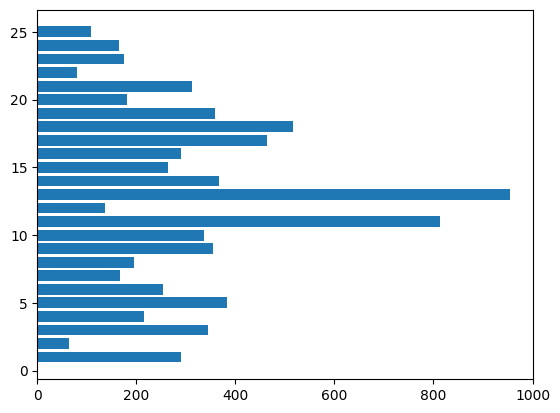

In [ ]:
plt.barh(category_counts.index, category_counts.values)
plt.show()

## Handle Missing Values

In [ ]:
df.isna().sum()

,0
fdc_id,0
protein,0
total_lipid_fat,0
carbohydrate_by_difference,0
energy,0
fiber_total_dietary,562
potassium_k,277
sodium_na,84
cholesterol,399
fatty_acids_total_trans,3614


In [ ]:
df['sugars_total'].value_counts()

,count
sugars_total,
0.00,2116
0.40,24
0.10,21
0.30,19
0.20,19
...,...
8.97,1
4.52,1
23.07,1


In [ ]:
df['sugars_total'].median()

1.34

In [9]:
df['fiber_total_dietary'] = df['fiber_total_dietary'].fillna(df['fiber_total_dietary'].median())
df['potassium_k'] = df['potassium_k'].fillna(df['potassium_k'].median())
df['sodium_na'] = df['sodium_na'].fillna(df['sodium_na'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())
df['fatty_acids_total_trans'] = df['fatty_acids_total_trans'].fillna(0)
df['fatty_acids_total_saturated'] = df['fatty_acids_total_saturated'].fillna(df['fatty_acids_total_saturated'].median())
df['sugars_total'] = df['sugars_total'].fillna(df['sugars_total'].median())

In [ ]:
df.isna().sum()

,0
fdc_id,0
protein,0
total_lipid_fat,0
carbohydrate_by_difference,0
energy,0
fiber_total_dietary,0
potassium_k,0
sodium_na,0
cholesterol,0
fatty_acids_total_trans,0


## Check Outliers

In [ ]:
df.columns

Index(['fdc_id', 'protein', 'total_lipid_fat', 'carbohydrate_by_difference',
       'energy', 'fiber_total_dietary', 'potassium_k', 'sodium_na',
       'cholesterol', 'fatty_acids_total_trans', 'fatty_acids_total_saturated',
       'sugars_total', 'description', 'food_category_id'],
      dtype='object')

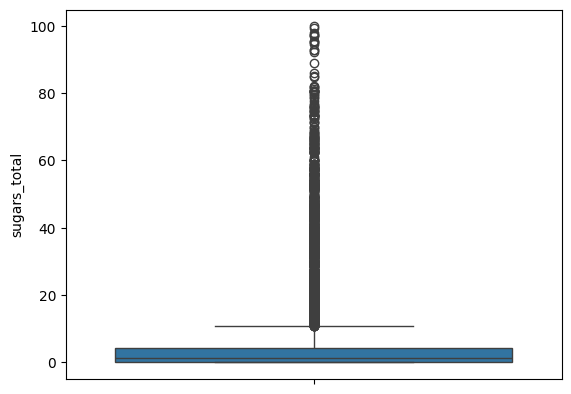

In [ ]:
sns.boxplot(y="sugars_total", data=df)
plt.show()

In [ ]:
df.loc[df.potassium_k > 10000, ["description","potassium_k"]]

,description,potassium_k
5293,"Leavening agents, baking powder, low-sodium",10100.0
7529,"Leavening agents, cream of tartar",16500.0


## Create Target Column

### Nutri-Score

Nutri-Score is calculated per 100g by subtracting positive points (fiber, protein, fruits/vegetables) from negative points (energy, sugar, salt, saturated fat)

In [10]:
energy_bins = [-1,80,160,240,320,400,480,560,640,720,800,np.inf]
sugar_bins = [-1,4.5,9,13.5,18,22.5,27,31,36,40,45,np.inf]
satfat_bins = [-1,1,2,3,4,5,6,7,8,9,10,np.inf]
sodium_bins = [-1,90,180,270,360,450,540,630,720,810,900,np.inf]
fiber_bins = [-1,0.7,1.4,2.1,2.8,3.5,np.inf]
protein_bins = [-1,1.6,3.2,4.8,6.4,8.0,np.inf]
fvnl_categories = [9, 11, 12, 16]

In [11]:
df["energy_points"] = pd.cut(df["energy"], bins=energy_bins, labels=range(11)).astype(int)
df["sugar_points"] = pd.cut(df["sugars_total"], bins=sugar_bins, labels=range(11)).astype(int)
df["satfat_points"] = pd.cut(df["fatty_acids_total_saturated"], bins=satfat_bins, labels=range(11)).astype(int)
df["salt_points"] = pd.cut(df["sodium_na"] * 2.5, bins=sodium_bins, labels=range(11)).astype(int)
df["fiber_points"] = pd.cut(df["fiber_total_dietary"], bins=fiber_bins, labels=range(6)).astype(int)
df["protein_points"] = pd.cut(df["protein"], bins=protein_bins, labels=range(6)).astype(int)
df["fvnl_points"] = np.where(df["food_category_id"].isin(fvnl_categories),5,0)

In [12]:
df["A_points"] = df["energy_points"] + df["sugar_points"] + df["satfat_points"] + df["salt_points"]
df["protein_points_adj"] = np.where((df["A_points"] >= 11) & (df["fvnl_points"] < 5), 0, df["protein_points"])
df["C_points"] = df["fiber_points"] + df["protein_points_adj"] + df["fvnl_points"]
df["nutri_score"] =  df["A_points"] - df["C_points"]

In [13]:
df["nutri_grade"] = pd.cut(
    df["nutri_score"],
    bins=[-np.inf, -1, 2, 10, 18, np.inf],
    labels=["A", "B", "C", "D", "E"]
)

In [14]:
label_counts = df["nutri_grade"].value_counts()
label_counts

,count
nutri_grade,
A,2472
D,1736
B,1500
C,1228
E,857


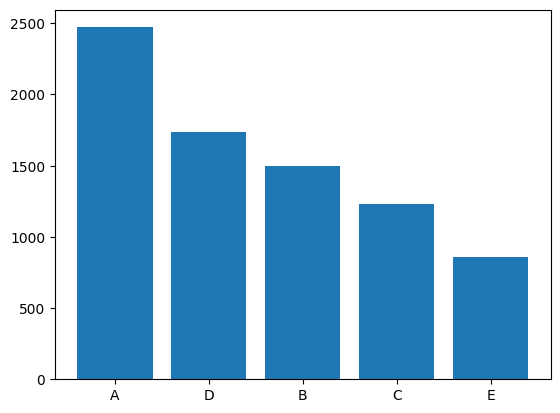

In [15]:
plt.bar(label_counts.index, label_counts.values)
plt.show()

In [16]:
df.head()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,...,satfat_points,salt_points,fiber_points,protein_points,fvnl_points,A_points,protein_points_adj,C_points,nutri_score,nutri_grade
0,167512,5.88,13.24,41.18,307.0,1.2,238.0,1059.0,0.0,4.412,...,2,10,1,3,0,16,0,1,15,D
1,167513,4.34,11.27,53.42,330.0,1.4,238.0,780.0,0.0,4.290,...,3,10,1,2,0,21,0,1,20,E
2,167514,6.10,3.70,79.80,377.0,0.3,238.0,2182.0,8.0,0.000,...,1,10,0,3,0,15,0,0,15,D
3,167515,8.00,1.80,46.00,232.0,0.3,238.0,345.0,8.0,0.082,...,0,9,0,4,0,11,0,0,11,D
4,167516,6.58,9.22,41.05,273.0,2.2,126.0,621.0,15.0,0.000,...,1,10,3,4,0,14,0,3,11,D


## Drop Unwanted Features

In [17]:
df.columns

Index(['fdc_id', 'protein', 'total_lipid_fat', 'carbohydrate_by_difference',
       'energy', 'fiber_total_dietary', 'potassium_k', 'sodium_na',
       'cholesterol', 'fatty_acids_total_trans', 'fatty_acids_total_saturated',
       'sugars_total', 'description', 'food_category_id', 'energy_points',
       'sugar_points', 'satfat_points', 'salt_points', 'fiber_points',
       'protein_points', 'fvnl_points', 'A_points', 'protein_points_adj',
       'C_points', 'nutri_score', 'nutri_grade'],
      dtype='object')

In [18]:
drop_cols = [
    "fdc_id",
    "description",
    "energy_points",
    "sugar_points",
    "satfat_points",
    "salt_points",
    "fiber_points",
    "protein_points",
    "fvnl_points",
    "A_points",
    "protein_points_adj",
    "C_points",
    "nutri_score"
]

df.drop(columns=drop_cols, axis=1, inplace=True)
df.shape

(7793, 13)

## Input Output Split

In [19]:
x = df.drop(['nutri_grade'], axis=1)
y = df['nutri_grade']

In [20]:
x.shape, y.shape

((7793, 12), (7793,))

## Feature Correlation

In [21]:
numeric_cols = [
    'protein',
    'total_lipid_fat',
    'carbohydrate_by_difference',
    'energy',
    'fiber_total_dietary',
    'potassium_k',
    'sodium_na',
    'cholesterol',
    'fatty_acids_total_trans',
    'fatty_acids_total_saturated',
    'sugars_total'
]

categorical_cols = ['food_category_id']

In [ ]:
x[numeric_cols].corr()

,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total
protein,1.000000,0.055735,-0.308815,0.126493,-0.079597,0.233522,0.003246,0.279239,-0.025669,0.044055,-0.268364
total_lipid_fat,0.055735,1.000000,-0.075165,0.825527,-0.015174,-0.036080,0.011505,0.084850,0.300593,0.761285,-0.022090
carbohydrate_by_difference,-0.308815,-0.075165,1.000000,0.434860,0.441473,0.153571,0.063945,-0.214379,-0.050234,-0.071910,0.587326
energy,0.126493,0.825527,0.434860,1.000000,0.187181,0.097066,0.049535,0.026186,0.222858,0.626029,0.258363
fiber_total_dietary,-0.079597,-0.015174,0.441473,0.187181,1.000000,0.342249,-0.000958,-0.141299,-0.044229,-0.072136,0.078361
potassium_k,0.233522,-0.036080,0.153571,0.097066,0.342249,1.000000,0.005136,-0.009069,-0.045265,-0.056983,0.005587
sodium_na,0.003246,0.011505,0.063945,0.049535,-0.000958,0.005136,1.000000,-0.014461,0.001193,0.000584,-0.000345
cholesterol,0.279239,0.084850,-0.214379,0.026186,-0.141299,-0.009069,-0.014461,1.000000,-0.000605,0.087445,-0.124408
fatty_acids_total_trans,-0.025669,0.300593,-0.050234,0.222858,-0.044229,-0.045265,0.001193,-0.000605,1.000000,0.185113,-0.026451
fatty_acids_total_saturated,0.044055,0.761285,-0.071910,0.626029,-0.072136,-0.056983,0.000584,0.087445,0.185113,1.000000,0.038657


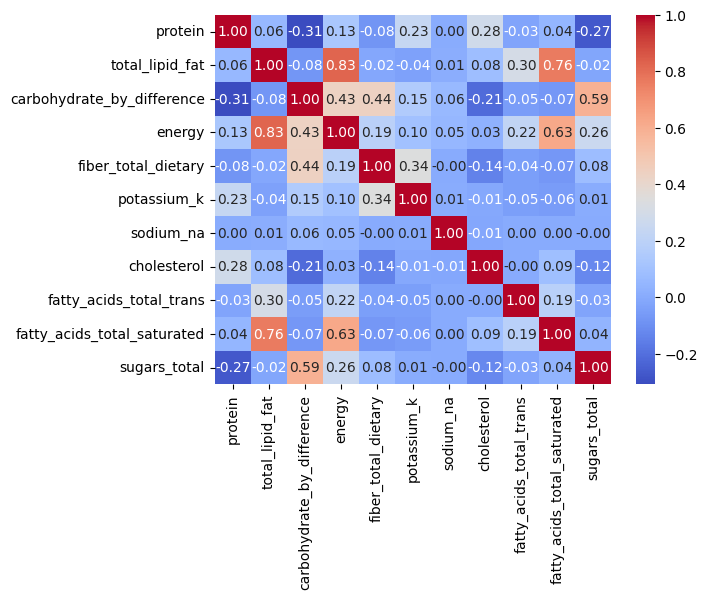

In [ ]:
sns.heatmap(x[numeric_cols].corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.show()

## Train Test Split

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
x_train.shape, x_test.shape

((6234, 12), (1559, 12))

# Model Creation

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

## KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline_knn = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

pipeline_knn.fit(x_train, y_train)
y_pred_knn = pipeline_knn.predict(x_test)

In [27]:
cm = confusion_matrix(y_test, y_pred_knn)
cm

array([[459,  22,   9,   3,   0],
       [ 63, 205,  18,   2,   0],
       [ 27,  53, 160,  28,   0],
       [  5,  13,  29, 280,  15],
       [  0,   0,   0,  22, 146]])

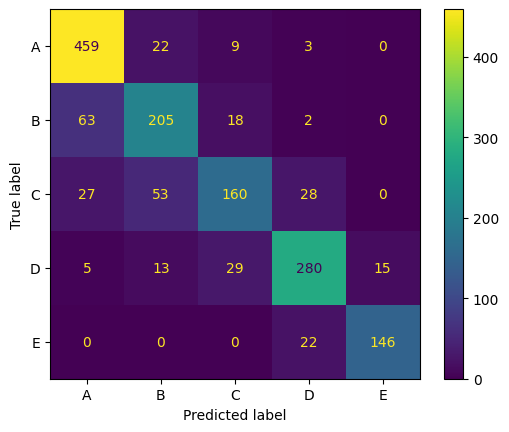

In [28]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [29]:
score_knn = accuracy_score(y_test, y_pred_knn)
score_knn

0.8017960230917255

In [30]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           A       0.83      0.93      0.88       493
           B       0.70      0.71      0.71       288
           C       0.74      0.60      0.66       268
           D       0.84      0.82      0.83       342
           E       0.91      0.87      0.89       168

    accuracy                           0.80      1559
   macro avg       0.80      0.79      0.79      1559
weighted avg       0.80      0.80      0.80      1559



## Naive Bayes

In [31]:
from sklearn.naive_bayes import GaussianNB

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

pipeline_nb = Pipeline([
    ('preprocessor', preprocessor_nb),
    ('classifier', GaussianNB())
])

pipeline_nb.fit(x_train, y_train)
y_pred_nb = pipeline_nb.predict(x_test)

In [32]:
cm = confusion_matrix(y_test, y_pred_nb)
cm

array([[352, 109,  12,   7,  13],
       [ 60, 196,  10,   4,  18],
       [ 40,  84,  41,  45,  58],
       [ 20,  41,  16, 154, 111],
       [  0,   1,   5,  14, 148]])

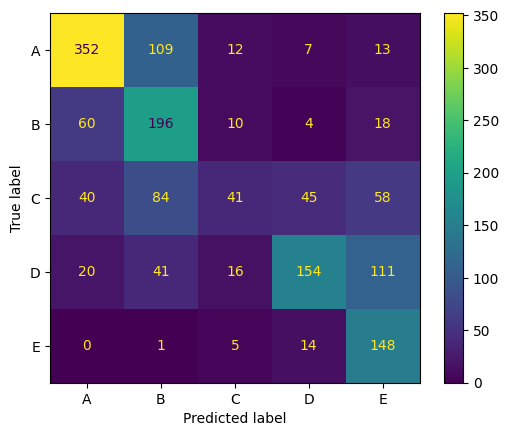

In [33]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [34]:
score_nb = accuracy_score(y_test, y_pred_nb)
score_nb

0.5715202052597819

In [35]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           A       0.75      0.71      0.73       493
           B       0.45      0.68      0.55       288
           C       0.49      0.15      0.23       268
           D       0.69      0.45      0.54       342
           E       0.43      0.88      0.57       168

    accuracy                           0.57      1559
   macro avg       0.56      0.58      0.53      1559
weighted avg       0.60      0.57      0.55      1559



## Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

preprocessor_dt = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline_dt = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', DecisionTreeClassifier(criterion='entropy', random_state=42))
])

pipeline_dt.fit(x_train, y_train)
y_pred_dt = pipeline_dt.predict(x_test)

In [37]:
cm = confusion_matrix(y_test, y_pred_dt)
cm

array([[463,  25,   5,   0,   0],
       [ 19, 245,  21,   3,   0],
       [  6,  29, 212,  19,   2],
       [  0,   4,  16, 305,  17],
       [  0,   0,   0,  16, 152]])

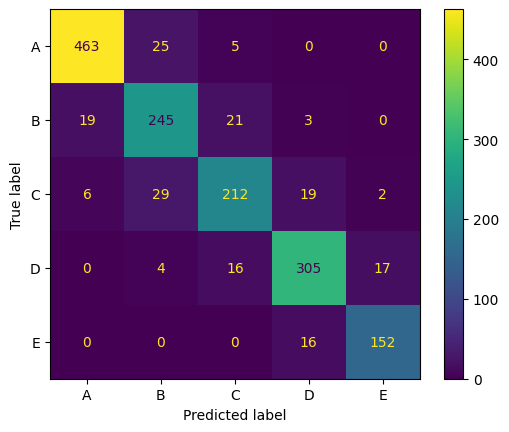

In [38]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [39]:
score_dt = accuracy_score(y_test, y_pred_dt)
score_dt

0.8832584990378448

In [40]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           A       0.95      0.94      0.94       493
           B       0.81      0.85      0.83       288
           C       0.83      0.79      0.81       268
           D       0.89      0.89      0.89       342
           E       0.89      0.90      0.90       168

    accuracy                           0.88      1559
   macro avg       0.87      0.88      0.87      1559
weighted avg       0.88      0.88      0.88      1559



## Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42))
])

pipeline_rf.fit(x_train, y_train)
y_pred_rf = pipeline_rf.predict(x_test)

In [42]:
cm = confusion_matrix(y_test, y_pred_rf)
cm

array([[476,  13,   4,   0,   0],
       [ 27, 251,   9,   1,   0],
       [  5,  30, 202,  31,   0],
       [  0,   0,  13, 320,   9],
       [  0,   0,   0,  11, 157]])

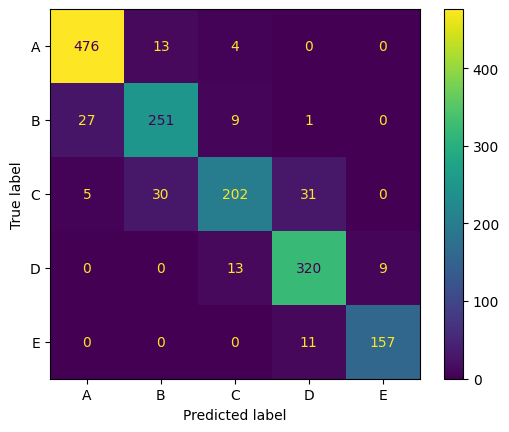

In [43]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [44]:
score_rf = accuracy_score(y_test, y_pred_rf)
score_rf

0.9018601667735728

In [45]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           A       0.94      0.97      0.95       493
           B       0.85      0.87      0.86       288
           C       0.89      0.75      0.81       268
           D       0.88      0.94      0.91       342
           E       0.95      0.93      0.94       168

    accuracy                           0.90      1559
   macro avg       0.90      0.89      0.90      1559
weighted avg       0.90      0.90      0.90      1559



# Model Comparison

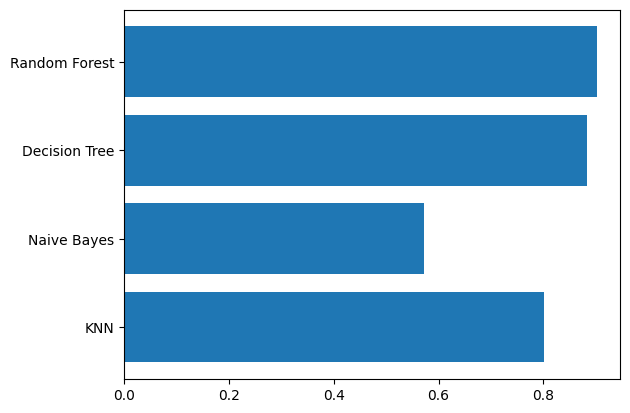

In [46]:
model_names = ['KNN', 'Naive Bayes', 'Decision Tree', 'Random Forest']
model_accuracy = [score_knn, score_nb, score_dt, score_rf]
plt.barh(model_names, model_accuracy)
plt.show()

# Hyperparameter Tuning

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__criterion': ['entropy', 'gini', 'log_loss']
}

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['protein',
                                                                          'total_lipid_fat',
                                                                          'carbohydrate_by_difference',
                                                                          'energy',
                                                                          'fiber_total_dietary',
                                                                          'potassium_k',
                                                                          'sodium_na',
                                                                          'cholesterol',
                                                                          'fatty_acids_total_trans',
                                                                          'fatty_acids_total_saturated',
                                                                          'sugars_total']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['food_category_id'])])),
                                       ('classifier',
                                        RandomForestClassifier(criterion='entropy',
                                                               random_state=42))]),
             param_grid={'classifier__criterion': ['entropy', 'gini',
                                                   'log_loss'],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [48]:
grid_search.best_params_

{'classifier__criterion': 'entropy', 'classifier__n_estimators': 100}

In [49]:
best_rf = grid_search.best_estimator_
best_rf.score(x_test, y_test)

0.9018601667735728

In [50]:
pipeline_rf.fit(x_train, y_train)
y_pred = pipeline_rf.predict(x_test)

# Performance Evaluation

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, y_pred_rf)
cm

array([[476,  13,   4,   0,   0],
       [ 27, 251,   9,   1,   0],
       [  5,  30, 202,  31,   0],
       [  0,   0,  13, 320,   9],
       [  0,   0,   0,  11, 157]])

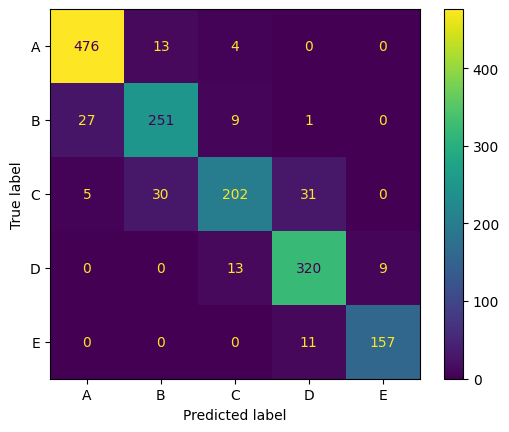

In [52]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [53]:
score = accuracy_score(y_test, y_pred_rf)
score

0.9018601667735728

In [54]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           A       0.94      0.97      0.95       493
           B       0.85      0.87      0.86       288
           C       0.89      0.75      0.81       268
           D       0.88      0.94      0.91       342
           E       0.95      0.93      0.94       168

    accuracy                           0.90      1559
   macro avg       0.90      0.89      0.90      1559
weighted avg       0.90      0.90      0.90      1559



# Custom Evaluation

In [55]:
custom_food = {
    'protein': 6.3,
    'total_lipid_fat': 4.8,
    'carbohydrate_by_difference': 0.36,
    'energy': 72,
    'fiber_total_dietary': 0,
    'potassium_k': 69,
    'sodium_na': 71,
    'cholesterol': 186,
    'fatty_acids_total_trans': 0.02,
    'fatty_acids_total_saturated': 1.6,
    'sugars_total': 0,
    'food_category_id': 1
}

custom_df = pd.DataFrame([custom_food])

In [56]:
prediction = pipeline_rf.predict(custom_df)

print("Predicted class:", prediction[0])

Predicted class: A


# Saving Model

In [57]:
import joblib

# Save model
joblib.dump(pipeline_rf, "pipeline_rf.pkl")

['pipeline_rf.pkl']